Extracted frames: 20
(20, 224, 224, 3)


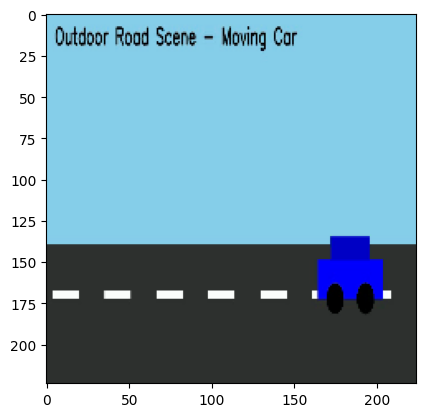

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
digital_clock : 63.84 %
traffic_light : 9.13 %
switch : 1.43 %
computer_keyboard : 1.32 %
matchstick : 0.85 %
Final Prediction: digital_clock


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Load pretrained MobileNetV2
model = MobileNetV2(weights='imagenet')

import cv2
import numpy as np

def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Handle videos where frame count is 0
    if total_frames > 0:
        step = max(1, total_frames // max_frames)
    else:
        step = 1

    count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # 🔴 Important fix
            frames.append(frame)

        count += 1

        if len(frames) >= max_frames:
            break

    cap.release()
    print("Extracted frames:", len(frames))
    frames_array = np.array(frames)

    # Now you can use .shape
    print(frames_array.shape)

    import matplotlib.pyplot as plt
    # OpenCV uses BGR, Matplotlib uses RGB, so we swap colors
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.show()

    return np.array(frames)



def classify_video(video_path):
    frames = extract_frames(video_path)

    if len(frames) == 0:
        print("No frames extracted!")
        return

    frames = preprocess_input(frames)
    predictions = model.predict(frames)
     # --- PRINT REQUESTED DATA ---
    print(f"SHAPE OF THE FRAMES ARRAY: {frames.shape}")
    print("FIRST ELEMENT OF THE ARRAY (FIRST FRAME DATA):")
    print(frames[0])
    # ----------------------------

    # Preprocess frames for the model
    processed_frames = preprocess_input(frames.copy())

    # Predict
    predictions = model.predict(processed_frames)

    # Average predictions across frames
    avg_pred = np.mean(predictions, axis=0)
    #top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=1)

    top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=5)

    for pred in top_pred[0]:
      print(pred[1], ":", round(pred[2]*100, 2), "%")


    print("Final Prediction:", top_pred[0][0][1])

# Replace with your video path
video_path = "real_world_demo_video.mp4"
classify_video(video_path)


FRAME 0 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


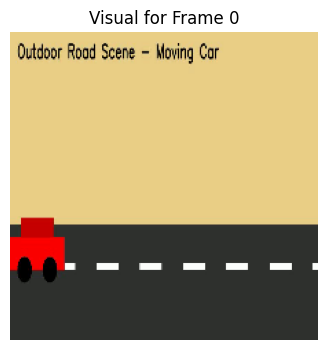


FRAME 1 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


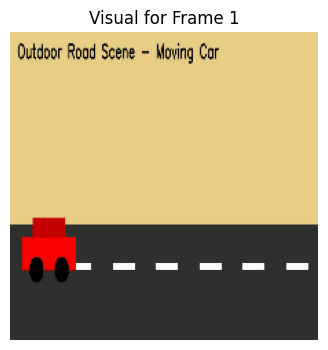


FRAME 2 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


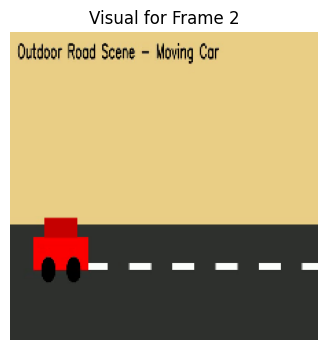


FRAME 3 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


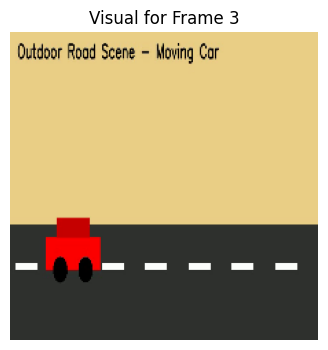


FRAME 4 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


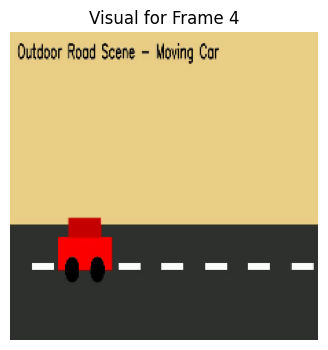


FRAME 5 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


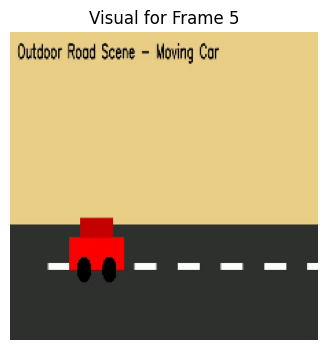


FRAME 6 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


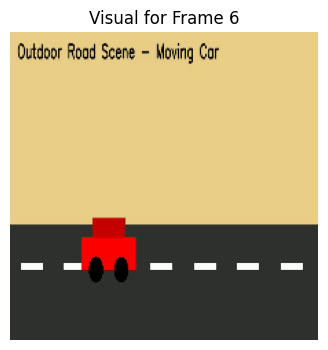


FRAME 7 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


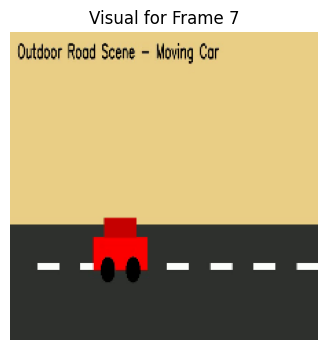


FRAME 8 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


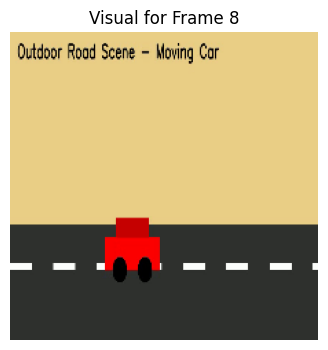


FRAME 9 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


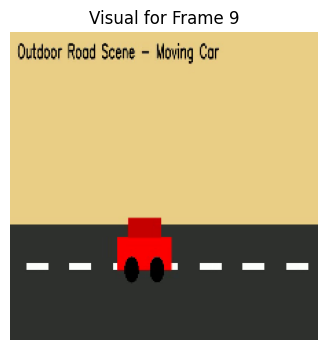


FRAME 10 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


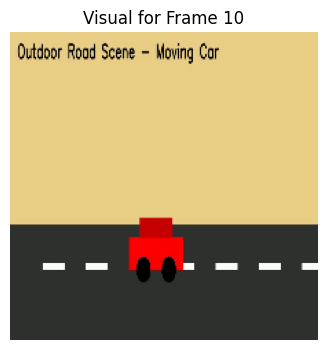


FRAME 11 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


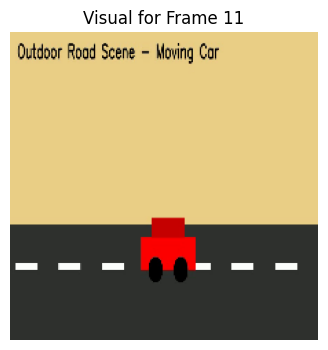


FRAME 12 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


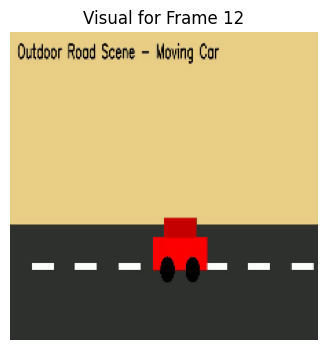


FRAME 13 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


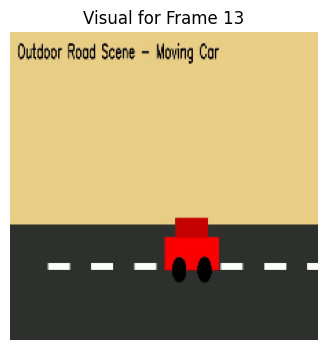


FRAME 14 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


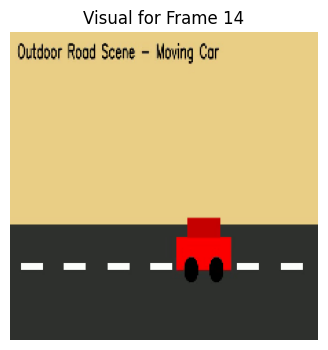


FRAME 15 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


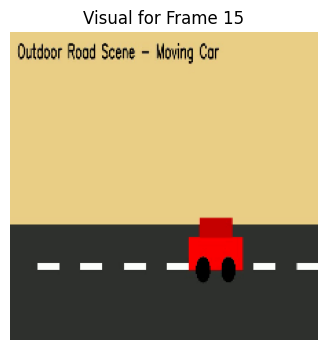


FRAME 16 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


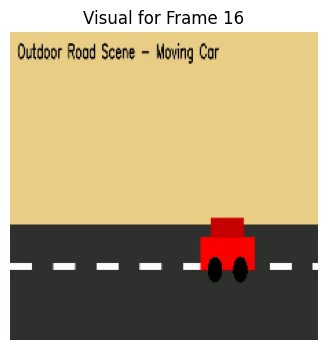


FRAME 17 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


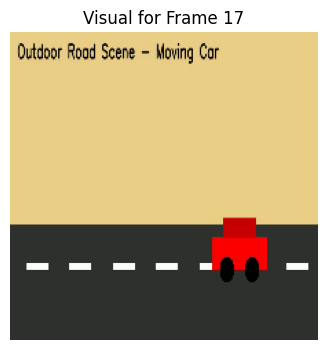


FRAME 18 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


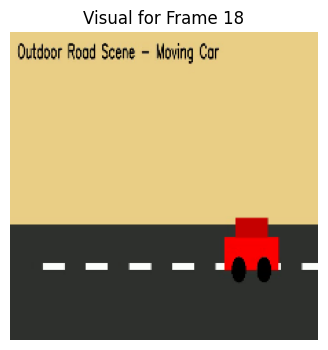


FRAME 19 - 3D MATRIX (H, W, RGB)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


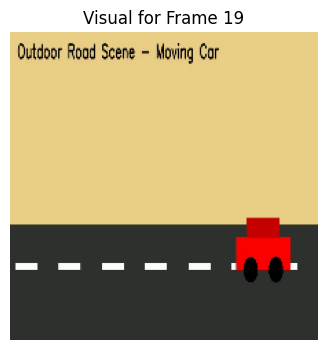

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configure NumPy to show matrix structure
np.set_printoptions(threshold=100, edgeitems=3, precision=0, suppress=True)

def extract_frames_with_visuals(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total_frames // max_frames) if total_frames > 0 else 1
    count = 0

    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            # 1. Resize and Convert Color
            frame_resized = cv2.resize(frame, (224, 224))
            frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)

            # 2. Print the 3D Matrix
            print(f"\n{'='*30}")
            print(f"FRAME {len(frames)} - 3D MATRIX (H, W, RGB)")
            print(f"{'='*30}")
            print(frame_rgb) # Displays as [ [ [R,G,B], [R,G,B]... ] ]

            # 3. Display the Image
            plt.figure(figsize=(4, 4))
            plt.imshow(frame_rgb)
            plt.title(f"Visual for Frame {len(frames)}")
            plt.axis('off')
            plt.show()

            frames.append(frame_rgb)

        count += 1

    cap.release()
    return np.array(frames)

# Run the updated function
video_path = "/content/real_world_demo_video.mp4"
extracted_frames = extract_frames_with_visuals(video_path)